In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [3]:
df.shape

(45000, 14)

In [4]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [5]:
# extracting numerical columns from the dataset
df_num_cols = df.select_dtypes(include = ['int64', 'float64'])

# percentage of numerical missing values in the dataset
missingvalues_percentage = df_num_cols.isnull().mean() * 100
print(missingvalues_percentage)

person_age                    0.0
person_income                 0.0
person_emp_exp                0.0
loan_amnt                     0.0
loan_int_rate                 0.0
loan_percent_income           0.0
cb_person_cred_hist_length    0.0
credit_score                  0.0
loan_status                   0.0
dtype: float64


In [6]:
# Check negative & zero values in numeric columns from dataset
# Check negative & zero values in numeric columns from dataset

df_num_cols = df.select_dtypes(include=['int64', 'float64'])

df_num_summary = pd.DataFrame(
    {
        'Negative count' : (df_num_cols < 0).sum(),
        'zero values': (df_num_cols == 0).sum(),
        'negative_%': (df_num_cols < 0).mean() * 100,
        'Zero_values_%' : (df_num_cols == 0).mean() *100
    }
)
print(df_num_summary)

                            Negative count  zero values  negative_%  \
person_age                               0            0         0.0   
person_income                            0            0         0.0   
person_emp_exp                           0         9566         0.0   
loan_amnt                                0            0         0.0   
loan_int_rate                            0            0         0.0   
loan_percent_income                      0           27         0.0   
cb_person_cred_hist_length               0            0         0.0   
credit_score                             0            0         0.0   
loan_status                              0        35000         0.0   

                            Zero_values_%  
person_age                       0.000000  
person_income                    0.000000  
person_emp_exp                  21.257778  
loan_amnt                        0.000000  
loan_int_rate                    0.000000  
loan_percent_income      

In [7]:
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [8]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [9]:
df_num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print('numerical columns: ', df_num_cols)

df_str_cols = df.select_dtypes(exclude =['int64', 'float64']).columns
print(f'\nobject columns: , {df_str_cols}')

numerical columns:  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='str')

object columns: , Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='str')


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

### Understanding data my visuals

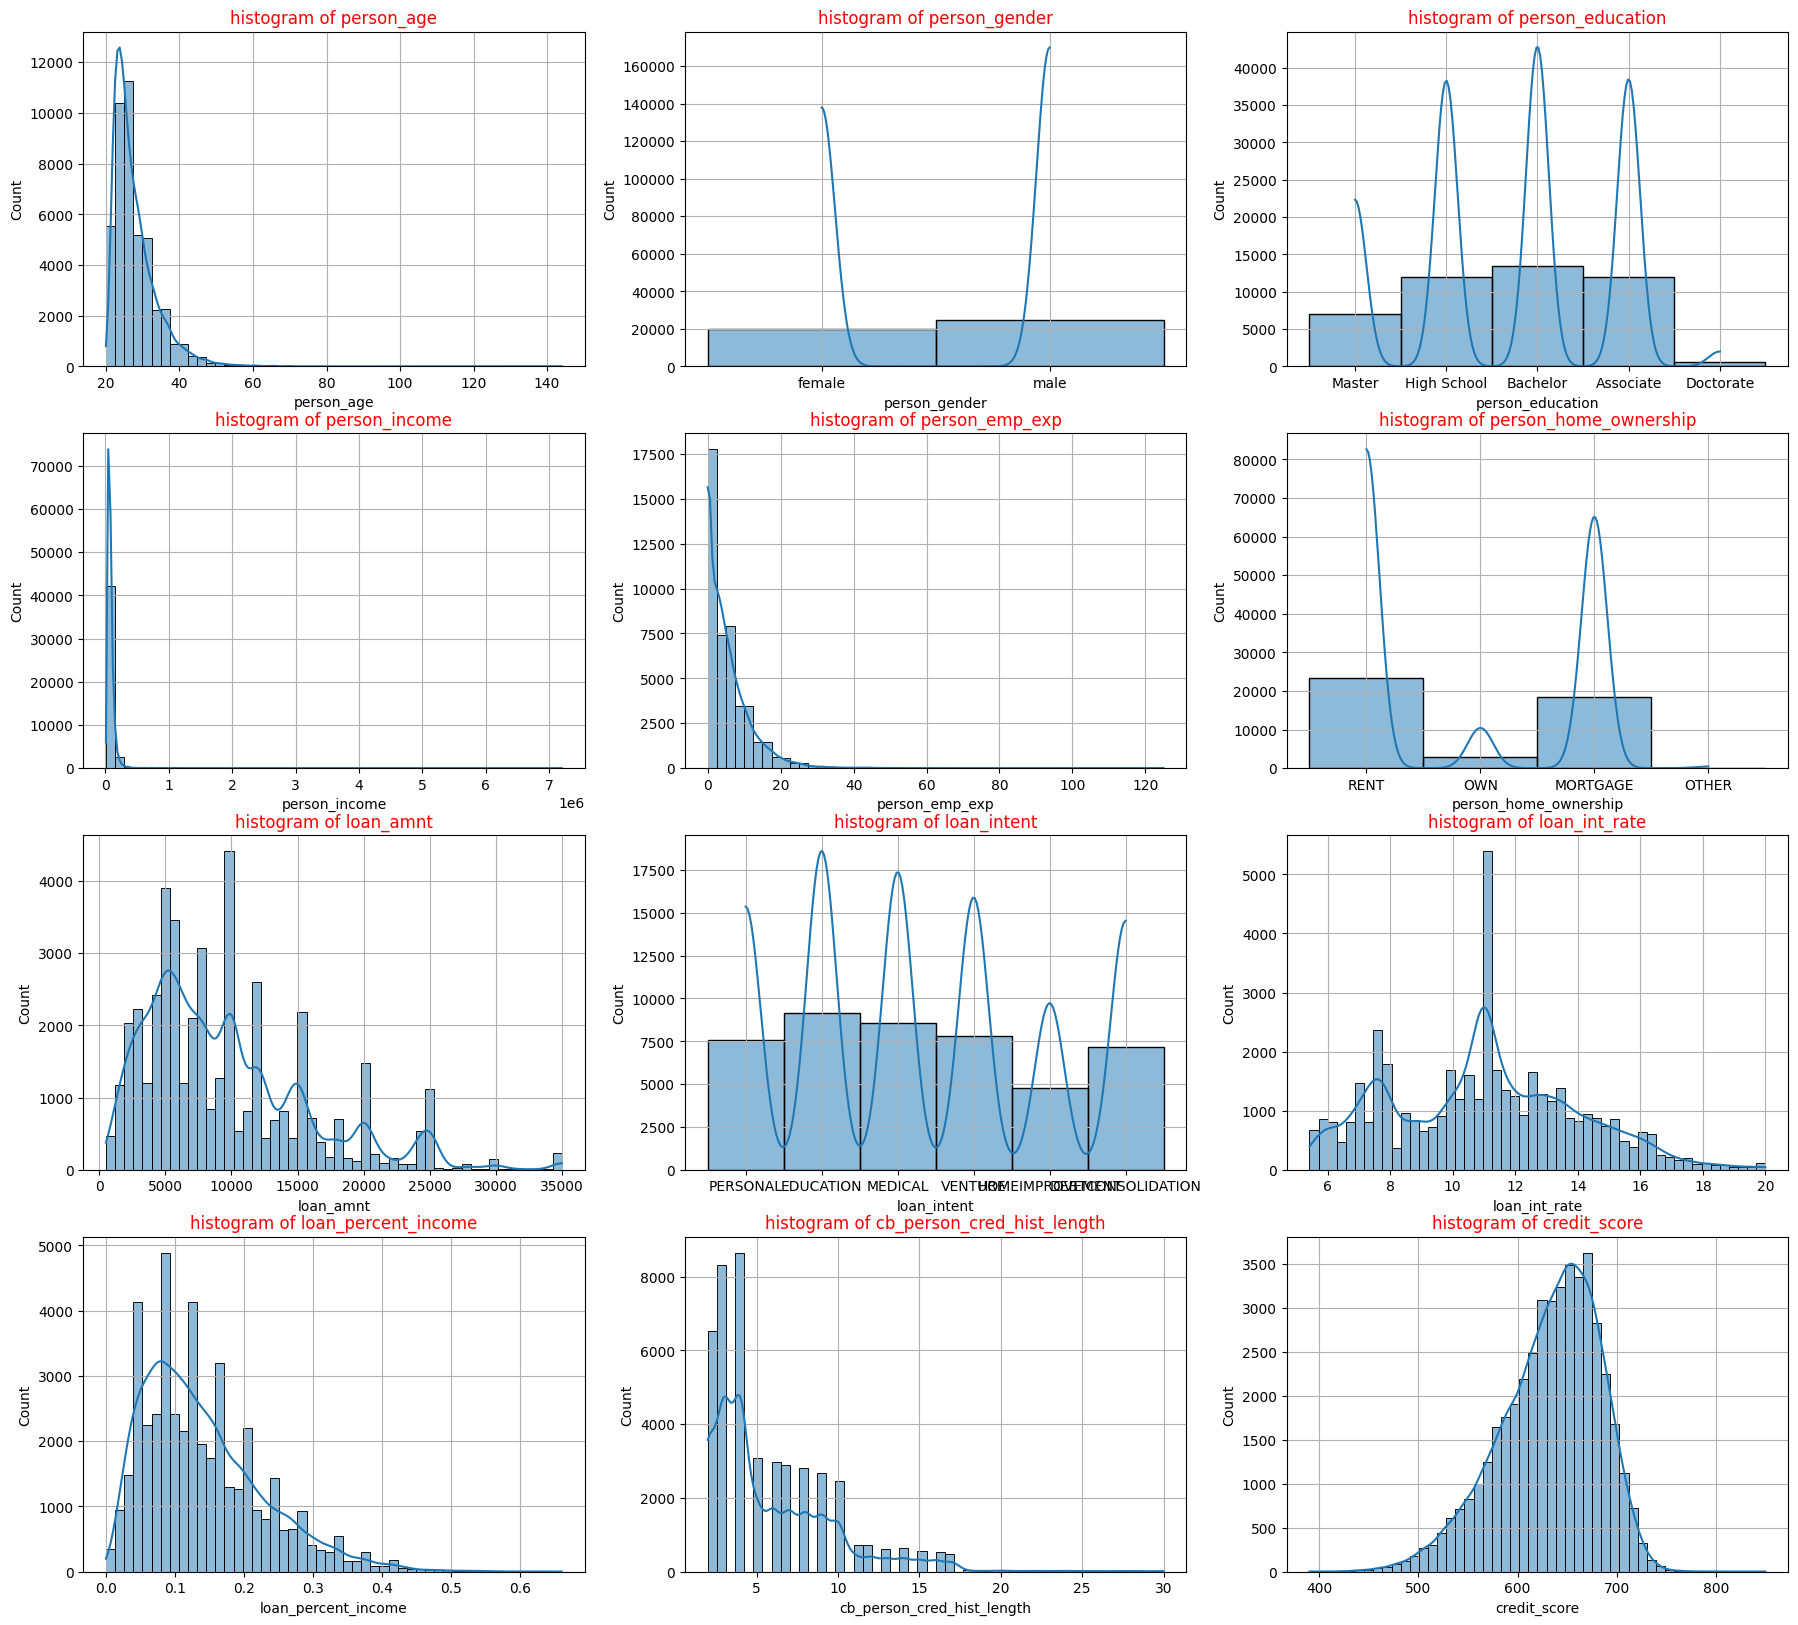

In [11]:
# Understanding the distribution of the dataset

fig, axes = plt.subplots(4, 3, figsize = (22, 20))

for i,ax in enumerate(axes.flatten()):
    if i>=len(df.columns)-1:
        break
    sns.histplot(data=df,
                 x=df[df.columns[i]],
                 ax=ax,
                 bins =50,
                 kde=True)
    ax.set_title(f"histogram of {df.columns[i]}", color= 'red')
    ax.grid(True)

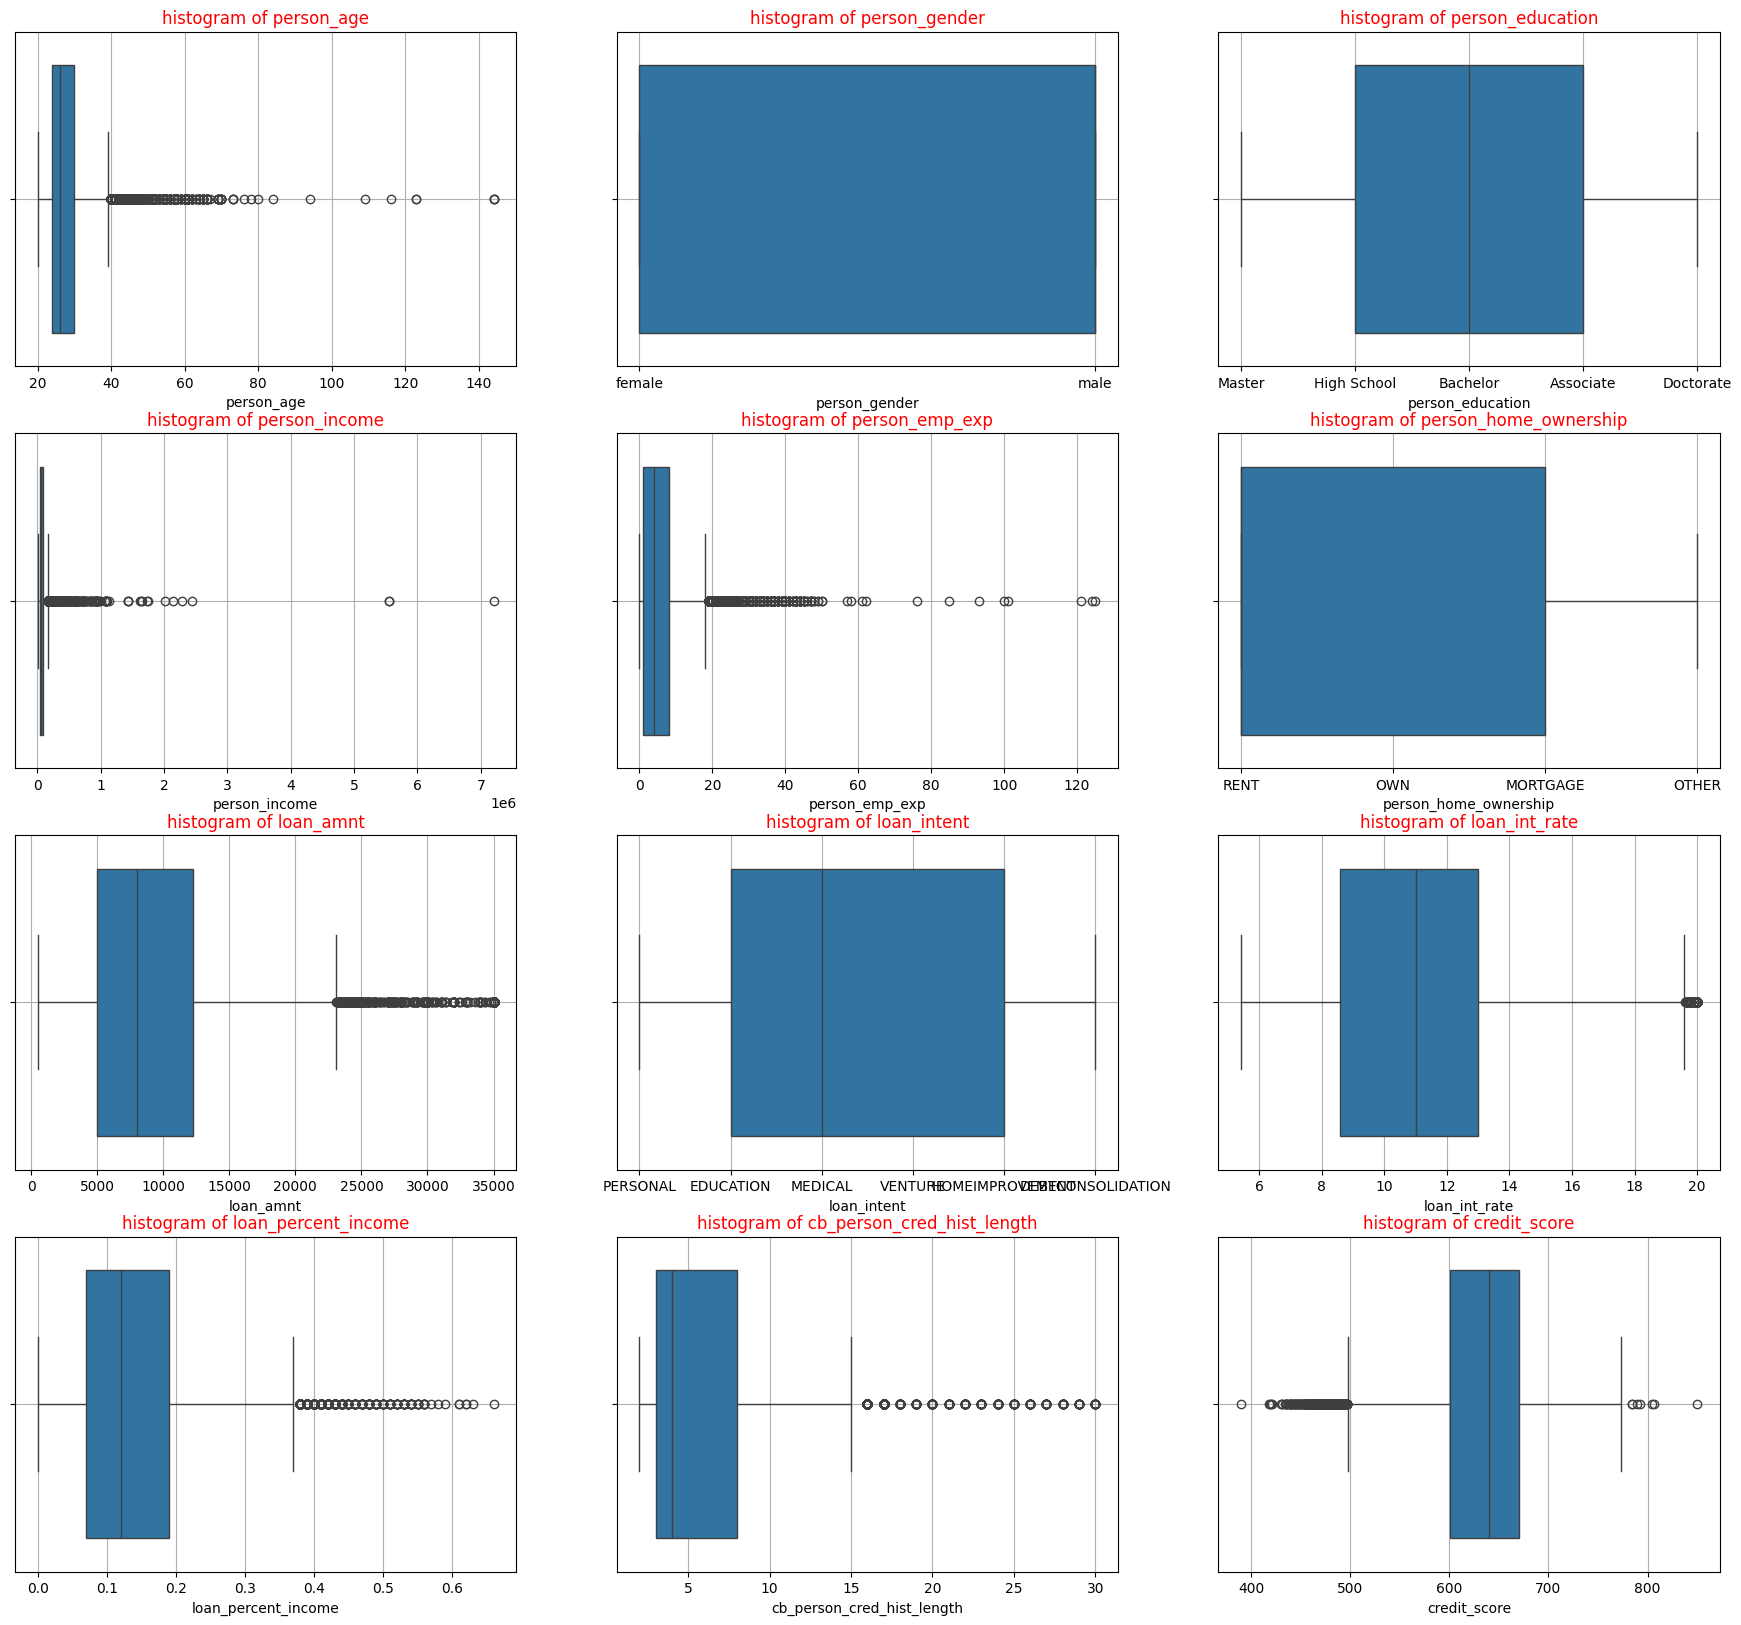

In [12]:
# boxplot to check the outliers in the dataset

fig, axes = plt.subplots(4, 3, figsize = (22, 20))

for i,ax in enumerate(axes.flatten()):
    if i>=len(df.columns)-1:
        break
    sns.boxplot(data=df,
                 x=df[df.columns[i]],
                ax =ax)
    ax.set_title(f"histogram of {df.columns[i]}", color= 'red')
    ax.grid(True)

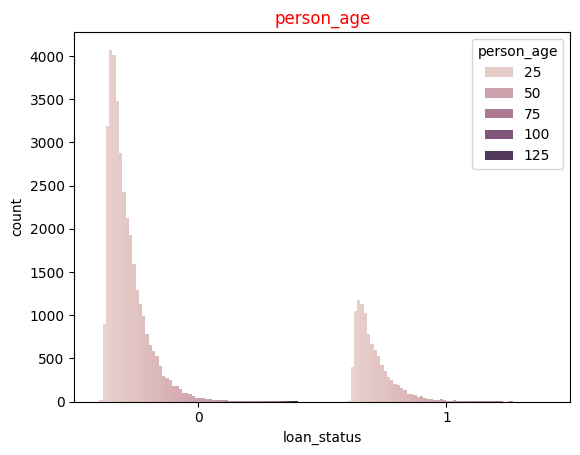

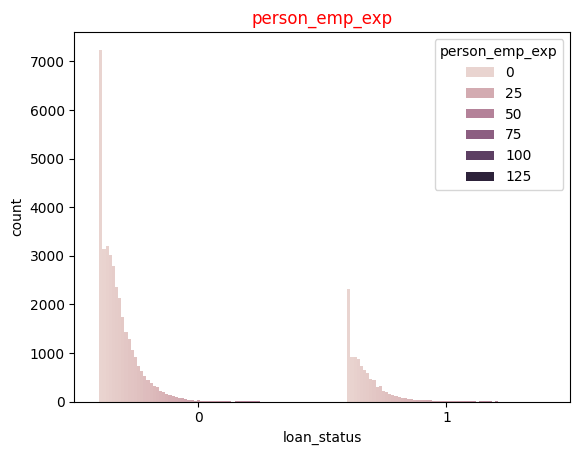

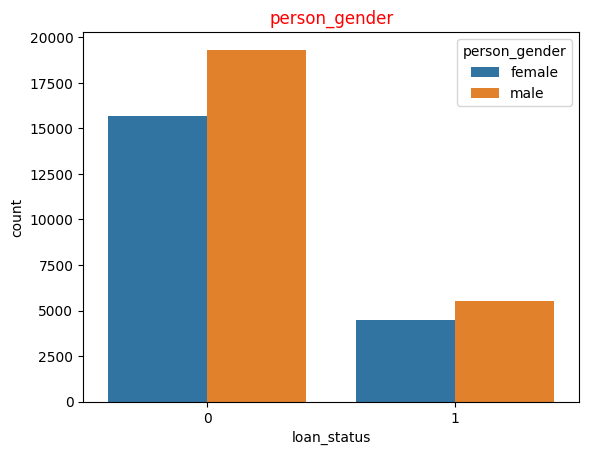

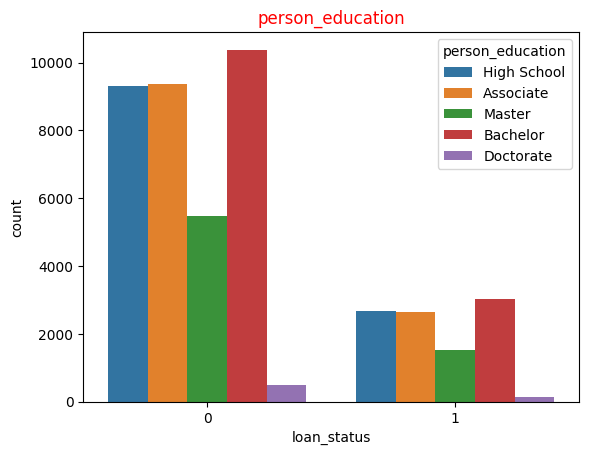

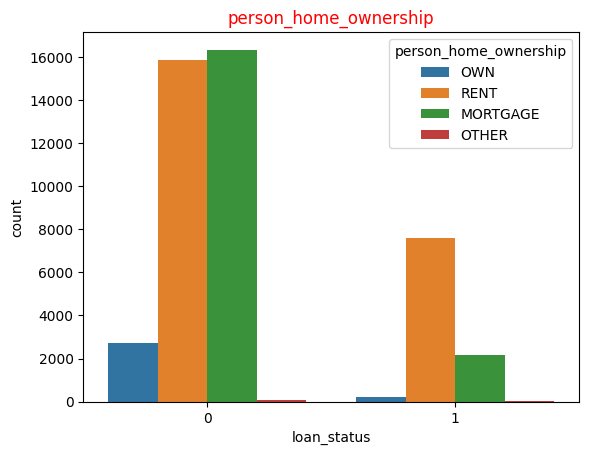

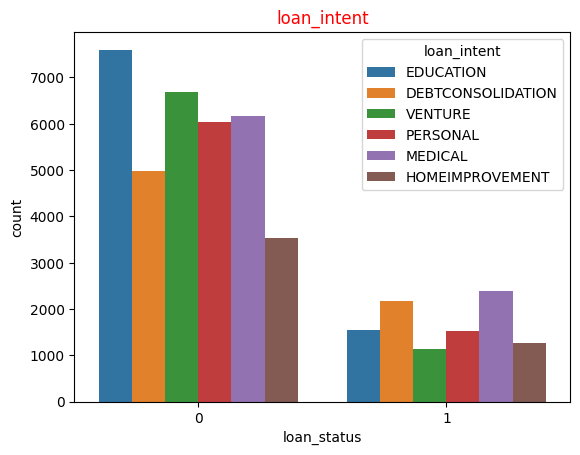

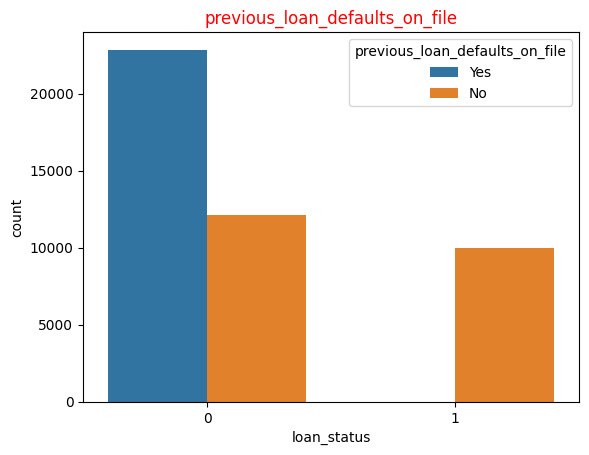

In [13]:
# data distribution with respect to target variable(loan Status)

def plot_chart(col):
    sns.countplot(data =df,
                  x= 'loan_status',
                  hue = col)
    plt.title(col, color  = 'red')
    plt.show()

col_list = 'person_age person_emp_exp person_gender person_education person_home_ownership loan_intent previous_loan_defaults_on_file'.split()

for col in col_list:
    plot_chart(col)

In [14]:
df['loan_status'].value_counts(normalize=True)* 100  # dataset is highly imbalace

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

### spliting the dataset

In [15]:
X = df.drop('loan_status', axis = 1)
y = df['loan_status']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y, random_state= 42)

print(f'\n shape of X-train data: {X_train.shape}')
print(f'\n shape of  X-test: {X_test.shape}')
print(f'\n shape of  y-train: {y_test.shape}')
print(f'\n shape of  y-test: {y_test.shape}')


 shape of X-train data: (31500, 13)

 shape of  X-test: (13500, 13)

 shape of  y-train: (13500,)

 shape of  y-test: (13500,)


## handling outliers

In [17]:
# create a function that can handle outliers

strong_cols = [
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

mild_cols = [
    'person_age',
    'credit_score',
    'loan_int_rate'
]


import numpy as np

def apply_iqr_capping(X_train, X_test, cols, factor):
    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in cols:
        if col not in X_train.columns:
            raise ValueError(f"Unknown column: {col}")

        q1 = X_train[col].quantile(0.25)
        q3 = X_train[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - factor * iqr
        upper = q3 + factor * iqr

        X_train[col] = np.clip(X_train[col], lower, upper)
        X_test[col] = np.clip(X_test[col], lower, upper)

    return X_train, X_test


In [18]:
X_train, X_test = apply_iqr_capping(
    X_train, X_test, strong_cols, factor=1.5
)

X_train, X_test = apply_iqr_capping(
    X_train, X_test, mild_cols, factor=3.0
)


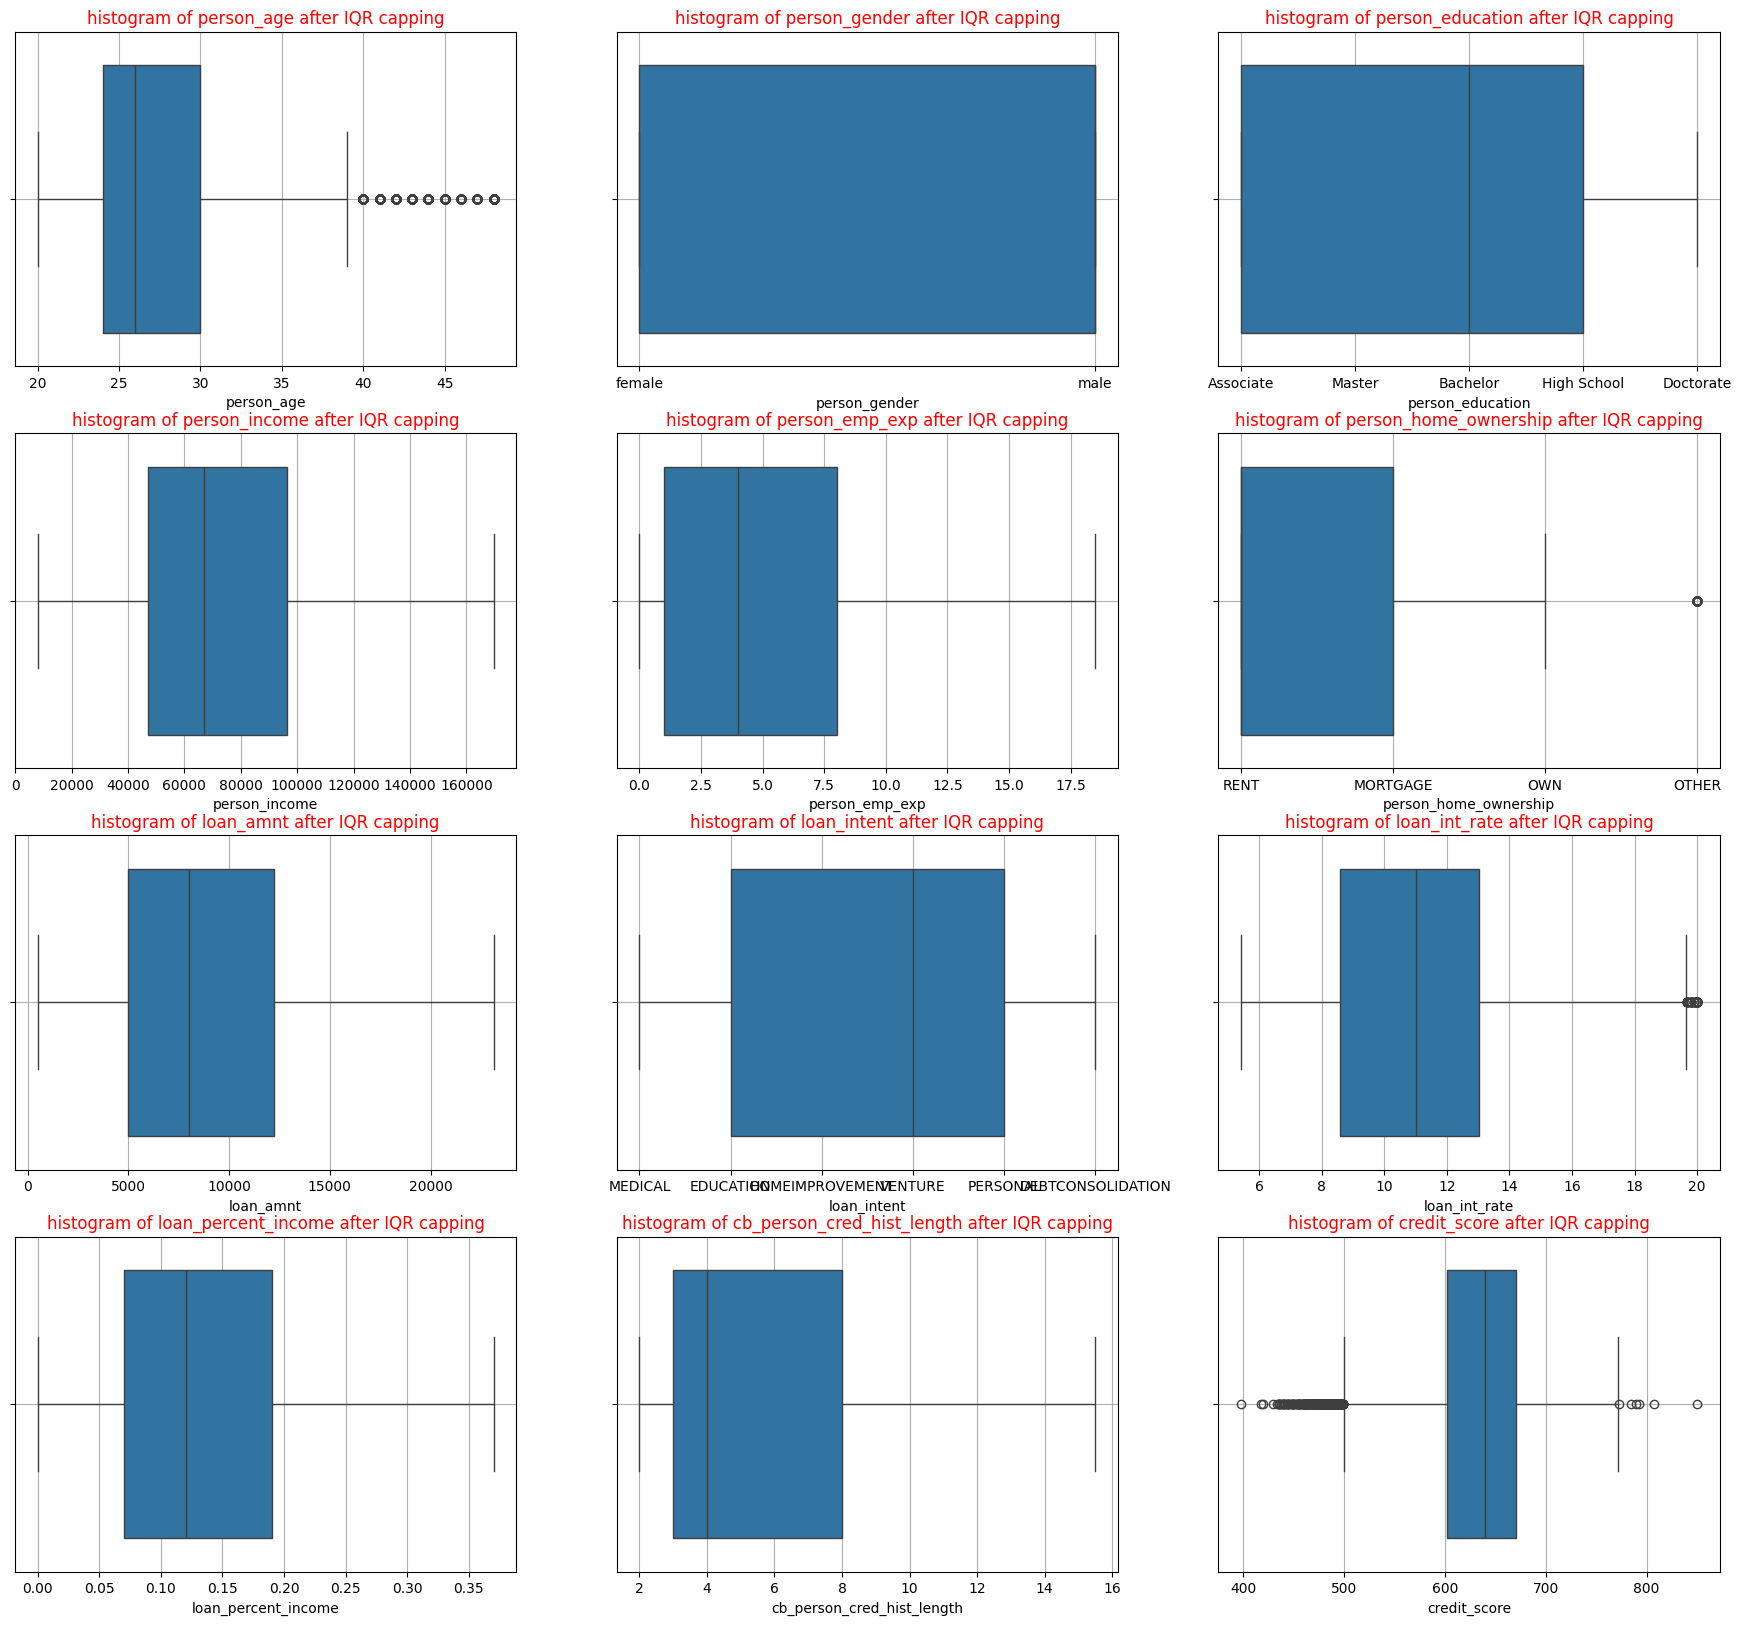

In [19]:
# boxplot to check the outliers in the dataset

fig, axes = plt.subplots(4, 3, figsize = (22, 20))

for i,ax in enumerate(axes.flatten()):
    if i>=len(X_train.columns)-1:
        break
    sns.boxplot(data=X_train,
                 x=X_train[X_train.columns[i]],
                ax =ax)
    ax.set_title(f"histogram of {X_train.columns[i]} after IQR capping", color= 'red')
    ax.grid(True)

In [20]:
# Appling log transform on person income
X_train['person_income'] = np.log1p(X_train['person_income'])
X_test['person_income'] = np.log1p(X_test['person_income'])

### Featuer encoding

In [ ]:
X_train['']

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler

# numerical columns 
numerical_cols  = X_train.select_dtypes(exclude= ['object', 'str']).columns

# binary column
binary_column = ['previous_loan_defaults_on_file']
# Ordinal categorical (ranking matters)
ordinal_cols = ['person_education']

# Nominal categorical
ohe_cols = [
    'person_gender',
    'person_home_ownership',
    'loan_intent'
]

def binary_yes_no_mapper(X):
    return X.replace({'Yes': 1, 'No': 0})

binary_pipeline = Pipeline([
    ('bin_map', FunctionTransformer(binary_yes_no_mapper))
])

# Using onehotEncoder for linear models
categorical_pipeline =  Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Using OrdinalEncoder for tree based model
categorical_pipeline_ordinal = Pipeline([
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value= -1
    ))
])

edu_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[['High School','Associate','Bachelor','Master','Doctorate'
    ]]))
])


In [22]:
# created transformer for linear models
encoding_col_linear = ColumnTransformer([
    ('binary_column', binary_pipeline, binary_column),
    ('ordinal_columns',edu_pipeline ,ordinal_cols ),
    ('ohe_columns',categorical_pipeline , ohe_cols),
    ('scaling', StandardScaler(), numerical_cols)

], remainder='passthrough')


# created transformer fpr tree models
encoding_col_tree = ColumnTransformer([
    ('binary_column', binary_pipeline, binary_column),
    ('ordinal_columns',edu_pipeline ,ordinal_cols ),
    ('ohe_columns',categorical_pipeline, ohe_cols)
], remainder= 'passthrough')

display(encoding_col_linear)
display(encoding_col_tree)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary_column', ...), ('ordinal_columns', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_n

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary_column', ...), ('ordinal_columns', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_n

In [ ]:
# linear models for classification
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier

# Tree based models for classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

# Metrics

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score


linear_models = {'LogisticRegression' : LogisticRegression(),
                'Naive bayes' : GaussianNB(),
                'Support vector Classifier' : SVC(probability= True),
                 'K Nearest Neighbor' :KNeighborsClassifier(),
                 'RidgeClassifier' : RidgeClassifier()}


tree_models  = {'DesicionTreeClassifier' :  DecisionTreeClassifier(),
               'Gradient Boosting Classifier' : GradientBoostingClassifier(),
                'AdaBoostClassifier' : AdaBoostClassifier(),
                'RandomForestClassifier': RandomForestClassifier(),
                'ExtraTreesClassifier' : ExtraTreesClassifier(),
               }

In [24]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

for i, (model_name, model) in enumerate(linear_models.items()):

    linear_model_pipeline = Pipeline(steps=[
        ('Columns_Encoding', encoding_col_linear),
        ('Smoting', SMOTE(random_state= 42)),
        ('model', model)
    ])

    linear_model = linear_model_pipeline.fit(X_train, y_train)
    y_pred = linear_model.predict(X_test)

    print(f'\n')
    print(f' {'=' * 20} {model_name} {'=' * 20}')
    print(f'Confusion metrix: \n{confusion_matrix(y_test, y_pred)}')
    print(f'Classification_report: {classification_report(y_test, y_pred )}')
    print(f'{'-' * 10} roc_auc score {'-' * 10}')
    print(f'roc_auc score: {roc_auc_score(y_test, y_pred)}')




 ==================== LogisticRegression ====================
Confusion metrix: 
[[8978 1522]
 [ 274 2726]]
Classification_report:               precision    recall  f1-score   support

           0       0.97      0.86      0.91     10500
           1       0.64      0.91      0.75      3000

    accuracy                           0.87     13500
   macro avg       0.81      0.88      0.83     13500
weighted avg       0.90      0.87      0.87     13500

---------- roc_auc score ----------
roc_auc score: 0.8818571428571428


 ==================== Naive bayes ====================
Confusion metrix: 
[[7152 3348]
 [  62 2938]]
Classification_report:               precision    recall  f1-score   support

           0       0.99      0.68      0.81     10500
           1       0.47      0.98      0.63      3000

    accuracy                           0.75     13500
   macro avg       0.73      0.83      0.72     13500
weighted avg       0.87      0.75      0.77     13500

---------- roc_au

In [25]:
# tree models

for i, (model_name, model) in enumerate(tree_models.items()):

    tree_model_pipeline = Pipeline(steps=[
        ('Columns_Encoding', encoding_col_linear),
        ('Smoting', SMOTE(random_state= 42)),
        ('model', model)
    ])

    tree_model = tree_model_pipeline.fit(X_train, y_train)
    y_pred = tree_model.predict(X_test)

    print(f'\n')
    print(f' {'=' * 20} {model_name} {'-' * 20}')
    print(f'Confusion metrix: \n{confusion_matrix(y_test, y_pred)}')
    print(f'Classification_report: {classification_report(y_test, y_pred )}')
    print(f'{'-' * 10} roc_auc score {'-' * 10}')
    print(f'roc_auc score: {roc_auc_score(y_test, y_pred)}')




 ==================== DesicionTreeClassifier --------------------
Confusion metrix: 
[[9622  878]
 [ 589 2411]]
Classification_report:               precision    recall  f1-score   support

           0       0.94      0.92      0.93     10500
           1       0.73      0.80      0.77      3000

    accuracy                           0.89     13500
   macro avg       0.84      0.86      0.85     13500
weighted avg       0.90      0.89      0.89     13500

---------- roc_auc score ----------
roc_auc score: 0.8600238095238094


 ==================== Gradient Boosting Classifier --------------------
Confusion metrix: 
[[9506  994]
 [ 397 2603]]
Classification_report:               precision    recall  f1-score   support

           0       0.96      0.91      0.93     10500
           1       0.72      0.87      0.79      3000

    accuracy                           0.90     13500
   macro avg       0.84      0.89      0.86     13500
weighted avg       0.91      0.90      0.90     135

### Hyperparameter Tuning

In [26]:
randomcv_models  =  [
    
 ('LogisticRegression', LogisticRegression(max_iter=500), {
    'model__penalty': ['l2'],
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__class_weight': ['balanced', None]
}),


('RidgeClassifier', RidgeClassifier(),
    {
    'model__alpha' : [0.01, 0.1, 1, 10, 100, 1000],
    'model__solver' : ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs' ],
    'model__class_weight': [None, 'balanced'],
    'model__fit_intercept' : [True, False],
}),

('DecisionTreeClassifier', DecisionTreeClassifier(), {
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced', None]
}),



('GaussianNB', GaussianNB(), {
    'model__var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}),

('RandomForestClassifier', RandomForestClassifier(), 
             {
    'model__n_estimators': [100, 200, 300],
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__bootstrap': [True, False],
    'model__class_weight': ['balanced', None]
}),

('SupportVectorClassifier', SVC(), 
             {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__gamma': ['scale', 'auto'],
    'model__class_weight': ['balanced', None]
}),


('K-NN', KNeighborsClassifier(), {
    'model__n_neighbors' : [3, 4, 5, 6, 7, 8, 9, 10],
    'model__weights' :['uniform', 'distance'],
    'model__algorithm' :['auto', 'ball_tree', 'kd_tree', 'brute'],
    'model__metric': ['euclidean', 'manhattan', 'minkowski'],
    'model__p' : [1, 2]
}),

('AdaBoostClassifier', AdaBoostClassifier(), {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}),

('GradientBoostingClassifier', GradientBoostingClassifier(), {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__max_features': ['sqrt', 'log2', None]
}),

('ExtraTreesClassifier', ExtraTreesClassifier(), {
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None],
    'model__bootstrap': [True, False],
    'model__class_weight': ['balanced', 'balanced_subsample', None]
})]

In [27]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}

for name, model, params in randomcv_models:

    pipeline = Pipeline(steps=[
        ('Columns_Encoding', encoding_col_linear),
        ('Smoting', SMOTE(random_state=42)),
        ('model', model)
    ])
     
    randomcv = RandomizedSearchCV(
                                estimator= pipeline ,
                                param_distributions= params,
                                n_iter = 10,
                                cv= 2,
                                verbose = 1,
                                n_jobs = 4,
                                random_state = 42
                                )
    randomcv.fit(X_train, y_train)
    model_params[name] = randomcv.best_params_

for model_name in model_params:
    print(f'------------------------ Best params for {model_name}---------------------------')
    print(model_params[model_name])

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Fitting 2 folds for each of 6 candidates, totalling 12 fits
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Fitting 2 folds for each of 10 candidates, totalling 20 fits
------------------------ Best params for LogisticRegression---------------------------
{'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__class_weight': 'balanced', 'model__C': 0.1}
------------------------ Best params for RidgeClassifier---------------------------
{'model__solver': 'svd', 'model__fit_intercept': True, 'model__class_weight': 'balanced', 'model__alpha': 1000}
-----

In [28]:
linear_models = {'LogisticRegression' : LogisticRegression(solver ='lbfgs', 
                                                           penalty =  'l2', 
                                                           class_weight = 'balanced', 
                                                           C = 0.1),

                'Naive bayes' : GaussianNB(var_smoothing =  1e-07),
                
                'Support vector Classifier' : SVC(probability= True,
                                                  kernel =  'poly', 
                                                  gamma =  'auto',
                                                  class_weight =  'balanced',
                                                  C =  0.01),

                 'K Nearest Neighbor' :KNeighborsClassifier(weights =  'uniform', 
                                                            p =  1, 
                                                            n_neighbors = 8, 
                                                            metric =  'minkowski',
                                                            algorithm =  'brute'),

                 'RidgeClassifier' : RidgeClassifier(solver = 'svd',
                                                      fit_intercept =  True,
                                                      class_weight =  'balanced', 
                                                      alpha =  1000)}


tree_models  = {'DesicionTreeClassifier' :  DecisionTreeClassifier(min_samples_split=  10, 
                                                                max_depth =  10, 
                                                                criterion = 'log_loss',
                                                                class_weight =  None),

               'Gradient Boosting Classifier' : GradientBoostingClassifier(subsample= 0.6, 
                                                                           n_estimators= 300,
                                                                           min_samples_split= 10,
                                                                           min_samples_leaf= 1,
                                                                           max_features= 'sqrt',
                                                                           max_depth = 4,
                                                                           learning_rate= 0.05),

                'AdaBoostClassifier' : AdaBoostClassifier(n_estimators =  200, 
                                                          learning_rate =  1.0),

                'RandomForestClassifier': RandomForestClassifier(n_estimators =  100,
                                                                 min_samples_split =  10,
                                                                 min_samples_leaf =  2,
                                                                 max_features =  'log2',
                                                                max_depth = 30,
                                                                criterion = 'log_loss', 
                                                                class_weight = None, 
                                                                bootstrap =  False),

                'ExtraTreesClassifier' : ExtraTreesClassifier(min_samples_split=2, 
                                                              min_samples_leaf= 1, 
                                                              max_features= None, 
                                                              max_depth= None, 
                                                              criterion= 'gini',
                                                              class_weight= 'balanced_subsample', 
                                                              bootstrap= False),
               }


for i, (model_name, model) in enumerate(linear_models.items()):

    linear_model_pipeline = Pipeline(steps=[
        ('Columns_Encoding', encoding_col_linear),
        ('Smoting', SMOTE(random_state= 42)),
        ('model', model)
    ])

    linear_model = linear_model_pipeline.fit(X_train, y_train)
    y_pred = linear_model.predict(X_test)

    print(f'\n')
    print(f' {'=' * 20} {model_name} {'=' * 20}')
    print(f'Confusion metrix: \n{confusion_matrix(y_test, y_pred)}')
    print(f'Classification_report: {classification_report(y_test, y_pred )}')
    print(f'{'-' * 10} roc_auc score {'-' * 10}')
    print(f'roc_auc score: {roc_auc_score(y_test, y_pred)}')



 ==================== LogisticRegression ====================
Confusion metrix: 
[[8983 1517]
 [ 272 2728]]
Classification_report:               precision    recall  f1-score   support

           0       0.97      0.86      0.91     10500
           1       0.64      0.91      0.75      3000

    accuracy                           0.87     13500
   macro avg       0.81      0.88      0.83     13500
weighted avg       0.90      0.87      0.87     13500

---------- roc_auc score ----------
roc_auc score: 0.8824285714285715


 ==================== Naive bayes ====================
Confusion metrix: 
[[7155 3345]
 [  62 2938]]
Classification_report:               precision    recall  f1-score   support

           0       0.99      0.68      0.81     10500
           1       0.47      0.98      0.63      3000

    accuracy                           0.75     13500
   macro avg       0.73      0.83      0.72     13500
weighted avg       0.88      0.75      0.77     13500

---------- roc_au

In [29]:
# tree models

for i, (model_name, model) in enumerate(tree_models.items()):

    tree_model_pipeline = Pipeline(steps=[
        ('Columns_Encoding', encoding_col_linear),
        ('Smoting', SMOTE(random_state= 42)),
        ('model', model)
    ])

    tree_model = tree_model_pipeline.fit(X_train, y_train)
    y_pred = tree_model.predict(X_test)

    print(f'\n')
    print(f' {'=' * 20} {model_name} {'-' * 20}')
    print(f'Confusion metrix: \n{confusion_matrix(y_test, y_pred)}')
    print(f'Classification_report: {classification_report(y_test, y_pred )}')
    print(f'{'-' * 10} roc_auc score {'-' * 10}')
    print(f'roc_auc score: {roc_auc_score(y_test, y_pred)}')




 ==================== DesicionTreeClassifier --------------------
Confusion metrix: 
[[9219 1281]
 [ 341 2659]]
Classification_report:               precision    recall  f1-score   support

           0       0.96      0.88      0.92     10500
           1       0.67      0.89      0.77      3000

    accuracy                           0.88     13500
   macro avg       0.82      0.88      0.84     13500
weighted avg       0.90      0.88      0.89     13500

---------- roc_auc score ----------
roc_auc score: 0.8821666666666667


 ==================== Gradient Boosting Classifier --------------------
Confusion metrix: 
[[9696  804]
 [ 423 2577]]
Classification_report:               precision    recall  f1-score   support

           0       0.96      0.92      0.94     10500
           1       0.76      0.86      0.81      3000

    accuracy                           0.91     13500
   macro avg       0.86      0.89      0.87     13500
weighted avg       0.91      0.91      0.91     135

In [30]:
# Storing all trained models at one place
trained_pipelines = {}

# linear models
for model_name, model in linear_models.items():

    pipeline = Pipeline(steps=[
        ('Columns_Encoding', encoding_col_linear),
        ('Smoting', SMOTE(random_state=42)),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = pipeline

# tree models
for model_name, model in tree_models.items():

    pipeline = Pipeline(steps=[
        ('Columns_Encoding', encoding_col_linear),
        ('Smoting', SMOTE(random_state=42)),   # optional for trees
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = pipeline


In [31]:
trained_pipelines

{'LogisticRegression': Pipeline(steps=[('Columns_Encoding',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('binary_column',
                                                   Pipeline(steps=[('bin_map',
                                                                    FunctionTransformer(func=<function binary_yes_no_mapper at 0x00000291B3C2BD70>))]),
                                                   ['previous_loan_defaults_on_file']),
                                                  ('ordinal_columns',
                                                   Pipeline(steps=[('encoder',
                                                                    OrdinalEncoder(categories=[['High '
                                                                                                'School',
                                                                                                'Associat...
                        

## ROC_AUC_Curve

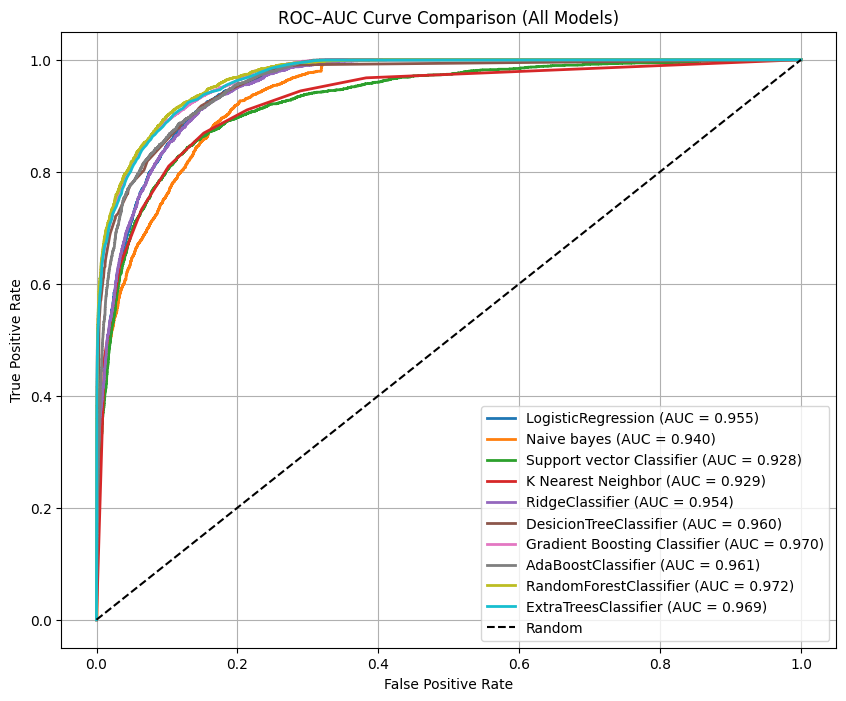

In [32]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, pipeline in trained_pipelines.items():

    model = pipeline.named_steps['model']

    # Use correct score type
    if hasattr(model, "predict_proba"):
        y_scores = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_scores = pipeline.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve Comparison (All Models)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [33]:

final_model = Pipeline(steps=[
    ('Columns_Encoding', encoding_col_linear),
    ('model', RandomForestClassifier(
        n_estimators=100,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features='log2',
        max_depth=30,
        criterion='log_loss',
        bootstrap=False,
        random_state=42
    ))
])


final_model.fit(X_train, y_train)


,steps,"[('Columns_Encoding', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary_column', ...), ('ordinal_columns', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a

In [34]:

from sklearn.metrics import f1_score

y_prob = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    scores.append(f1_score(y_test, y_pred_t))

best_threshold = thresholds[np.argmax(scores)]
best_threshold


np.float64(0.40000000000000013)

In [35]:
# instead of default 0.5
y_prob = final_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_prob >= 0.4).astype(int)

y_final_pred = (y_prob >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_final_pred))
print(classification_report(y_test, y_final_pred))


[[10075   425]
 [  573  2427]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     10500
           1       0.85      0.81      0.83      3000

    accuracy                           0.93     13500
   macro avg       0.90      0.88      0.89     13500
weighted avg       0.93      0.93      0.93     13500



### Saving the model for deployment

In [38]:
X_train.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file'],
      dtype='str')

In [39]:
import joblib

joblib.dump(final_model, 'loan_approval_model.pkl')

['loan_approval_model.pkl']